### Question Shuffle

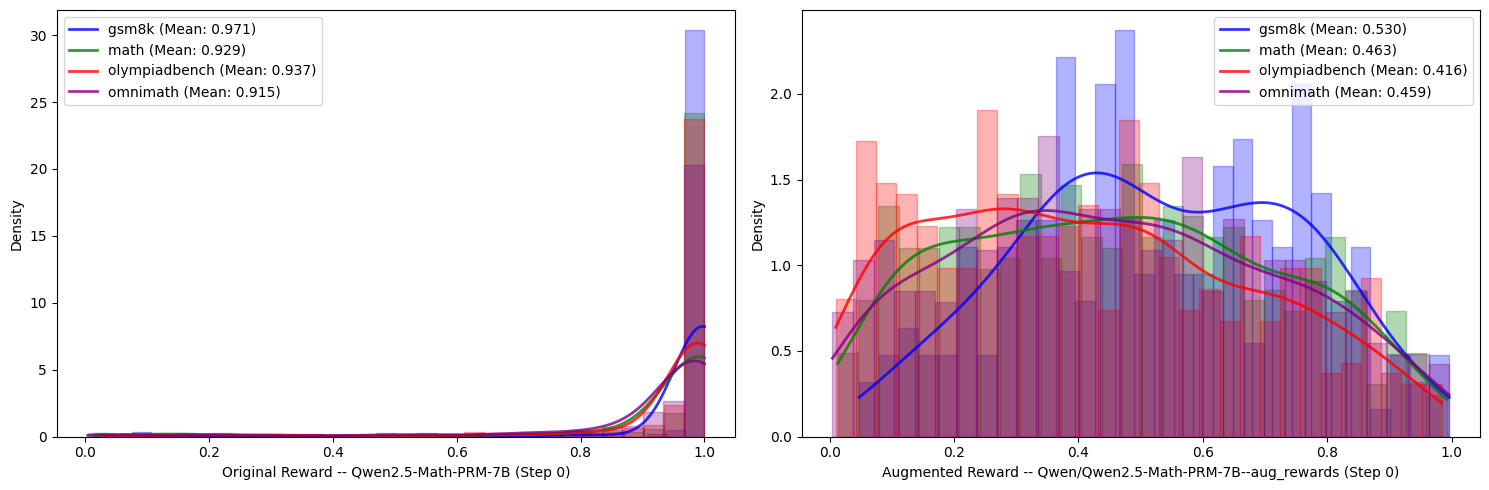

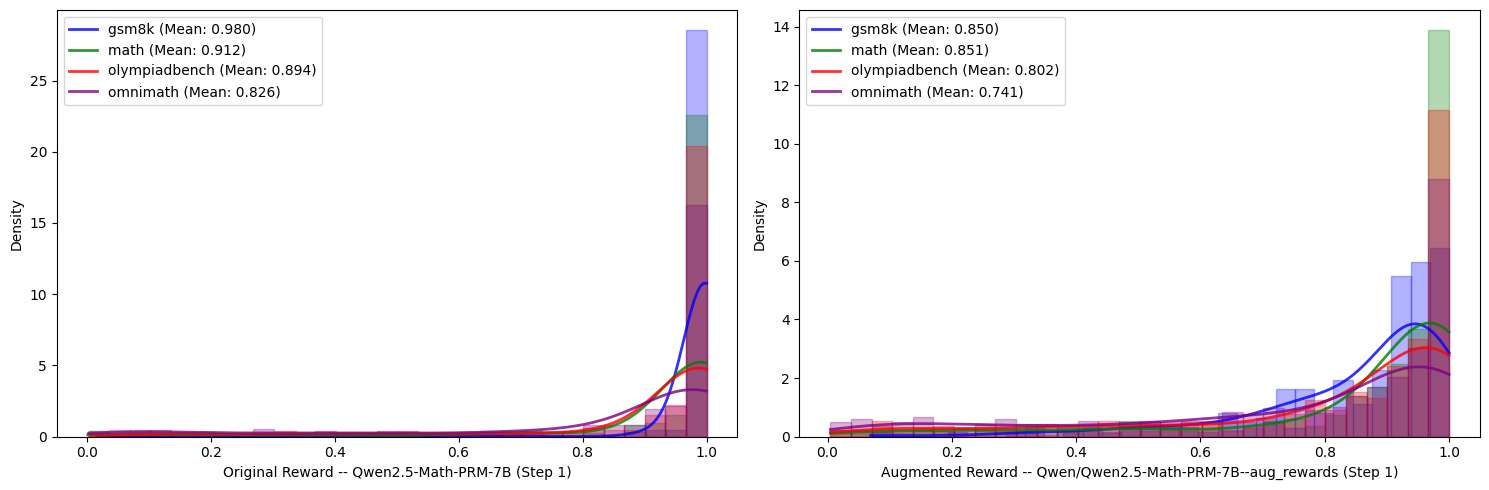

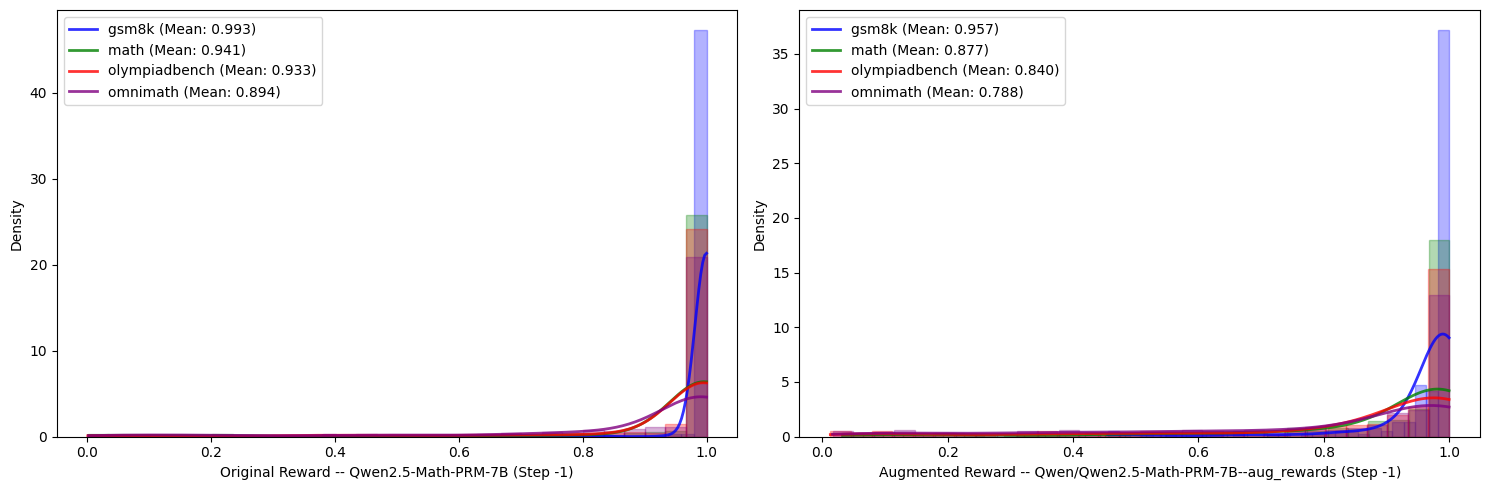

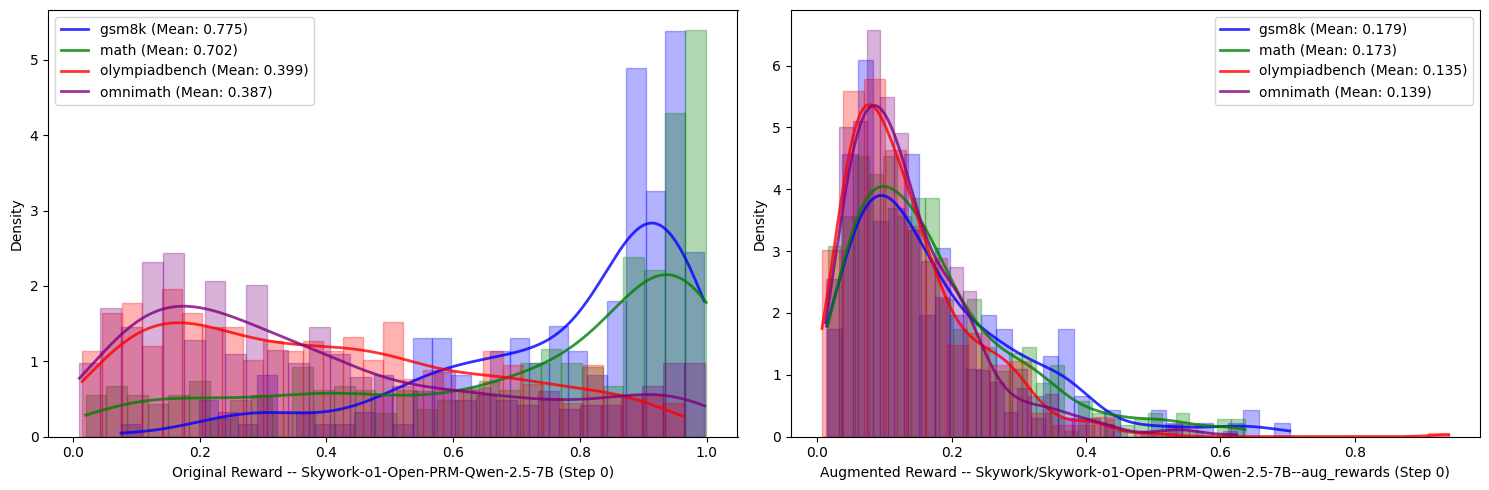

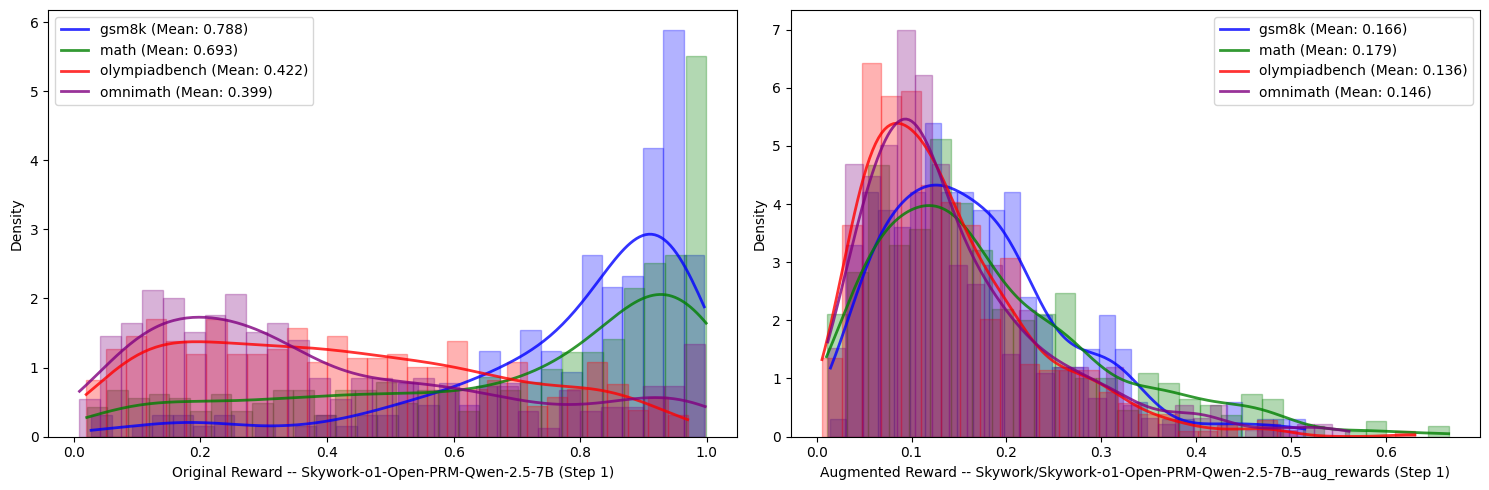

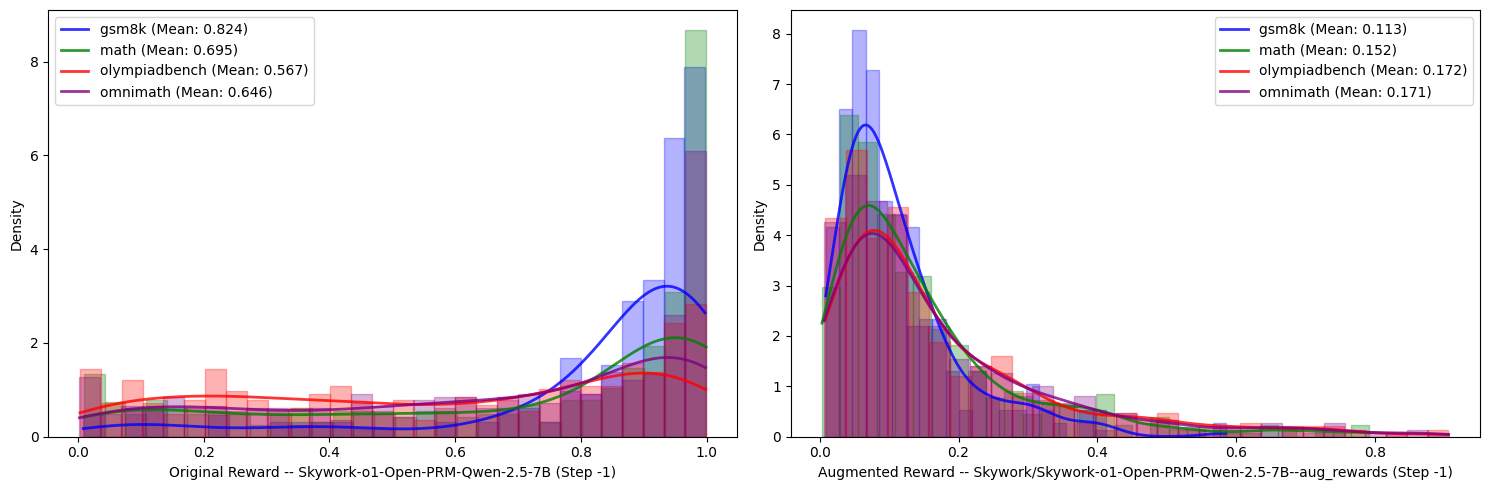

In [33]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

colors = ['blue', 'green', 'red', 'purple']
df = pd.read_parquet(f"experiments/question_shuffle/attack.parquet")
for model in (["Qwen2.5-Math-PRM-7B", "Qwen/Qwen2.5-Math-PRM-7B--aug_rewards"], ["Skywork-o1-Open-PRM-Qwen-2.5-7B", "Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards"]):
    for step_num in [0, 1, -1]:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        for i, dataset in enumerate(["gsm8k", "math", "olympiadbench", "omnimath"]):
            df_sample = df[df["split"] == dataset]
            df_sample = df_sample[df_sample["final_answer_correct"] == True]

            original_rewards = df_sample[model[0]].apply(lambda x: x[step_num]).to_numpy()
            augmented_rewards = df_sample[model[1]].apply(lambda x: x[step_num]).to_numpy()

            # Original plot
            ax1.hist(original_rewards, bins=30, density=True, alpha=0.3,
                    edgecolor=colors[i], color=colors[i])
            kde = stats.gaussian_kde(original_rewards)
            x_range = np.linspace(original_rewards.min(), original_rewards.max(), 200)
            ax1.plot(x_range, kde(x_range), color=colors[i], lw=2, alpha=0.8,
                    label=f'{dataset} (Mean: {original_rewards.mean():.3f})')

            # Augmented plot  
            ax2.hist(augmented_rewards, bins=30, density=True, alpha=0.3,
                    edgecolor=colors[i], color=colors[i])
            kde = stats.gaussian_kde(augmented_rewards)
            x_range = np.linspace(augmented_rewards.min(), augmented_rewards.max(), 200)
            ax2.plot(x_range, kde(x_range), color=colors[i], lw=2, alpha=0.8,
                    label=f'{dataset} (Mean: {augmented_rewards.mean():.3f})')

        ax1.set_xlabel(f'Original Reward -- {model[0]} (Step {step_num})')
        ax1.set_ylabel('Density')
        ax1.legend()

        ax2.set_xlabel(f'Augmented Reward -- {model[1]} (Step {step_num})')
        ax2.set_ylabel('Density')
        ax2.legend()

        plt.tight_layout()
        plt.show()